In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!pip -q install geopandas pyogrio shapely pyproj rtree rasterio folium pykrige

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 507.6/507.6 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.7/961.7 kB 48.0 MB/s eta 0:00:00


In [3]:
!pip -q install geopandas pyogrio shapely pyproj rtree rasterio folium

!pip -q install pykrige

In [4]:
import os
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point
from datetime import timedelta
from pykrige.ok import OrdinaryKriging
from pykrige.uk import UniversalKriging
import rasterio
from rasterio.transform import from_origin


In [5]:
# ----------------------------
# A) Parámetros de ENTRADA
# ----------------------------
# Nombres de archivos
RUTA_ESTACIONES = '/content/drive/MyDrive/TESIS/salida/INTERPOLACION/gjoindias.csv'
RUTA_EVENTOS    = '/content/drive/MyDrive/TESIS/salida/INTERPOLACION/dfeventos.csv'
RUTA_MASCARA= '/content/drive/MyDrive/TESIS /CAUCA/CAUCA.shp'

EPSG:9377


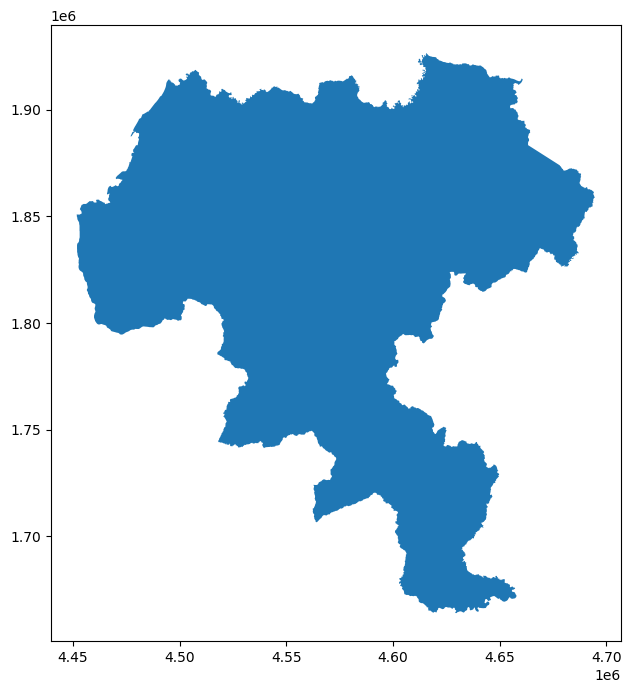

In [6]:
gdf_masc = gpd.read_file(RUTA_MASCARA)
print(gdf_masc.crs)  # Verifica el CRS
gdf_masc.plot(figsize=(8,8))
plt.show()


In [7]:
df_est = pd.read_csv(RUTA_ESTACIONES)
df_est['Fecha'] = pd.to_datetime(df_est['Fecha'], errors='coerce')
df_est['Precipitacion'] = pd.to_numeric(df_est['Precipitacion'], errors='coerce')

In [8]:
from shapely import wkt
geom_est = gpd.GeoSeries.from_wkt(df_est['geometry'])
gdf_est = gpd.GeoDataFrame(df_est.drop(columns=['geometry']), geometry=geom_est, crs='EPSG:4326')


In [9]:
df_evt = pd.read_csv(RUTA_EVENTOS, dtype={'Código_SIMMA':str})
df_evt['Fecha_even'] = pd.to_datetime(df_evt['Fecha_even'], errors='coerce')
gdf_evt = gpd.GeoDataFrame(
    df_evt,
    geometry=gpd.points_from_xy(df_evt['Longitud__'], df_evt['Latitud__i']),
    crs='EPSG:4326'
)


In [ ]:
CRS_EPSG = 9377  # ajusta al valor que imprima gdf_masc.crs
gdf_est = gdf_est.to_crs(CRS_EPSG)
gdf_evt = gdf_evt.to_crs(CRS_EPSG)
gdf_masc = gdf_masc.to_crs(CRS_EPSG)


# **3. Construcción del calendario de fechas a interpolar**

In [ ]:
VENTANAS = [1, 3, 7, 15, 30, 180]
fechas_necesarias = set()

# incluir t0
fechas_necesarias.update(gdf_evt['Fecha_even'].dt.date)

# incluir t0-n para todas las ventanas
for t0 in gdf_evt['Fecha_even'].dt.date:
    for w in VENTANAS:
        for d in range(1, w+1):
            fechas_necesarias.add(t0 - timedelta(days=d))

fechas_necesarias = sorted(fechas_necesarias)


In [ ]:
OUT_RASTERS_DIR = '/content/drive/MyDrive/TESIS/salida/INTERPOLACION/rasters_diarios'
os.makedirs(OUT_RASTERS_DIR, exist_ok=True)


In [ ]:
VARIO  = 'spherical'
RANGE  = 28000.0   # en metros, ajusta según tu variograma
NUGGET = 20.0      # valor inicial de nugget (mm²)
CELL   = 1586.2088 # tamaño de celda (en metros) similar a ArcGIS
N_PTS  = 12        # número de vecinos
N_MIN_PTS = 6      # mínimo de estaciones por día


In [ ]:
# Unificar la geometría de la máscara en un solo polígono. Esto servirá para
# seleccionar únicamente los centros de celda que caen dentro del área de
# estudio y evitar generar predicciones fuera del límite.
mask_poly = gdf_masc.unary_union

for fecha in fechas_necesarias:
    # Filtrar estaciones del día
    df_day = gdf_est[gdf_est['Fecha'].dt.date == fecha]
    if len(df_day) < N_MIN_PTS:
        # Saltar días con pocas estaciones (no se realiza interpolación)
        continue

    # Extraer coordenadas y valores de las estaciones
    x = df_day.geometry.x.values
    y = df_day.geometry.y.values
    z = df_day['Precipitacion'].values

    # Definir el bounding box de la máscara y calcular la cuadrícula completa
    minx, miny, maxx, maxy = gdf_masc.total_bounds
    n_x = int((maxx - minx) / CELL) + 1
    n_y = int((maxy - miny) / CELL) + 1
    # Coordenadas de los centros de cada celda
    xs = np.linspace(minx + CELL / 2.0, maxx - CELL / 2.0, n_x)
    ys = np.linspace(miny + CELL / 2.0, maxy - CELL / 2.0, n_y)

    # Generar lista de puntos centro de las celdas dentro de la máscara
    grid_points = []
    grid_indices = []  # índices de fila (iy) y columna (ix) para cada punto
    for iy, ycoord in enumerate(ys):
        for ix, xcoord in enumerate(xs):
            pt = Point(xcoord, ycoord)
            if mask_poly.contains(pt):
                grid_points.append(pt)
                grid_indices.append((iy, ix))

    # Si no hay puntos dentro de la máscara (improbable), continuar
    if not grid_points:
        print(f"Aviso: No se generaron puntos de predicción dentro de la máscara para {fecha}")
        continue

    # Extraer coordenadas separadas
    pred_x = np.array([p.x for p in grid_points])
    pred_y = np.array([p.y for p in grid_points])

    # Calcular los parámetros del variograma a partir de los datos del día
    sill = np.var(z)
    ok = OrdinaryKriging(
        x, y, z,
        variogram_model=VARIO,
        variogram_parameters={'sill': sill, 'range': RANGE, 'nugget': NUGGET},
        enable_plotting=False,
    )
    # Ejecutar kriging en modo 'points' para obtener predicciones únicamente en
    # los puntos que caen dentro del polígono de la máscara.
    z_pred, _ = ok.execute('points', pred_x, pred_y)
    z_pred = np.array(z_pred)
    # Ajustar valores negativos a cero (precipitación no puede ser negativa)
    z_pred[z_pred < 0] = 0.0

    # Crear un array 2D lleno de NaN con el tamaño de la cuadrícula completa
    z_mask = np.full((n_y, n_x), np.nan, dtype='float32')

    # Asignar las predicciones al array en las posiciones correspondientes
    for (iy, ix), val in zip(grid_indices, z_pred):
        z_mask[iy, ix] = val

    # Guardar el ráster con la matriz completa (NaN fuera de la máscara)
    out_tif = os.path.join(OUT_RASTERS_DIR, f'precip_{fecha}.tif')
    transform = from_origin(minx, maxy, CELL, CELL)
    with rasterio.open(
        out_tif,
        'w',
        driver='GTiff',
        height=z_mask.shape[0],
        width=z_mask.shape[1],
        count=1,
        dtype=z_mask.dtype,
        crs=gdf_est.crs,
        transform=transform,
        nodata=np.nan,
    ) as dst:
        dst.write(z_mask, 1)

/tmp/ipython-input-523133114.py:4: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  mask_poly = gdf_masc.unary_union


KeyboardInterrupt: 

In [ ]:
from pykrige.ok import OrdinaryKriging
# ... (u otro modelo si prefieres UniversalKriging)

for fd in fechas_necesarias:
    df_day = gdf_est[gdf_est['Fecha'].dt.date == fd]
    if len(df_day) < N_MIN_PTS:
        continue  # no se interpola
    x = df_day.geometry.x.values
    y = df_day.geometry.y.values
    z = df_day['Precipitacion'].values

    # Generar malla (grid) con las coordenadas mínimas y máximas de tu zona
    minx, miny, maxx, maxy = gdf_masc.total_bounds
    gridx = np.linspace(minx, maxx, int((maxx - minx) / CELL) + 1)
    gridy = np.linspace(miny, maxy, int((maxy - miny) / CELL) + 1)

    # Kriging ordinario
    OK = OrdinaryKriging(
        x, y, z,
        variogram_model=VARIO,
        variogram_parameters={'sill': np.var(z), 'range': RANGE, 'nugget': NUGGET},
        enable_plotting=False
    )
    z_grid, ss = OK.execute('grid', gridx, gridy)
    z_grid = np.array(z_grid)
    z_grid[z_grid < 0] = 0  # recorte de valores negativos

    # Guardar raster
    from rasterio.transform import from_origin
    transform = from_origin(minx, maxy, CELL, CELL)
    out_tif = os.path.join(OUT_RASTERS_DIR, f'precip_{fd}.tif')
    with rasterio.open(
        out_tif, 'w', driver='GTiff',
        height=z_grid.shape[0], width=z_grid.shape[1],
        count=1, dtype=z_grid.dtype,
        crs=gdf_est.crs,
        transform=transform
    ) as dst:
        dst.write(z_grid, 1)


KeyboardInterrupt: 

In [ ]:
# Ventanas a calcular (en días, todas hasta t0-1)
VENTANAS = [1, 3, 7, 15, 30, 180]

In [ ]:
CELL      = 1586.2088   # tamaño de celda (m) como en Entornos de ArcGIS
N_PTS     = 12          # vecindario: 12 puntos más cercanos
N_MIN_PTS = 6           # mínimo de estaciones para kriging ese día

In [ ]:
df_evt.head()

,Código_SIMMA,Fecha_even,Latitud__i,Longitud__,Fecha_t0_1d,Fecha_t0_3d,Fecha_t0_5d,Fecha_t0_7d,Fecha_t0_15d,Fecha_t0_30d,Fecha_t0_180d
0,32966,2005-10-05,2.812108,-76.763061,2005-10-04,2005-10-02,2005-09-30,2005-09-28,2005-09-20,2005-09-05,2005-04-08
1,32968,2005-10-12,2.708464,-76.769711,2005-10-11,2005-10-09,2005-10-07,2005-10-05,2005-09-27,2005-09-12,2005-04-15
2,53721,2005-11-01,2.075828,-76.664594,2005-10-31,2005-10-29,2005-10-27,2005-10-25,2005-10-17,2005-10-02,2005-05-05
3,54376,2005-11-01,2.188815,-76.793900,2005-10-31,2005-10-29,2005-10-27,2005-10-25,2005-10-17,2005-10-02,2005-05-05
4,55798,2005-11-01,2.621024,-76.574959,2005-10-31,2005-10-29,2005-10-27,2005-10-25,2005-10-17,2005-10-02,2005-05-05


In [ ]:
df_est.head()


,EstacionID,nombre,geometry,Fecha,Precipitacion,EstacionGrupo
0,26010030,PURACE [26010030],POINT (-76.45477777999997 2.380861110000069),2005-01-01 07:00:00,0.0,PTPM_CON
1,26010030,PURACE [26010030],POINT (-76.45477777999997 2.380861110000069),2005-01-02 07:00:00,0.0,PTPM_CON
2,26010030,PURACE [26010030],POINT (-76.45477777999997 2.380861110000069),2005-01-03 07:00:00,0.0,PTPM_CON
3,26010030,PURACE [26010030],POINT (-76.45477777999997 2.380861110000069),2005-01-04 07:00:00,5.0,PTPM_CON
4,26010030,PURACE [26010030],POINT (-76.45477777999997 2.380861110000069),2005-01-05 07:00:00,0.0,PTPM_CON


In [ ]:
# ========= Variograma (plantilla fija; sill se escala con varianza diaria) =========
VARIO         = 'spherical'
RANGE         = 28000.0   # m (si tienes el del Wizard, pon ese)
NUGGET        = 20.0      # mm^2
ANIS_SCALING  = 1.0       # 1.0 = isotrópico; si hay anisotropía: mayor/menor
ANIS_ANGLE    = 0.0       # grados del eje mayor


In [ ]:
# ========= Salidas =========
OUT_RASTERS_DIR = 'rasters_diarios'
OUT_CSV         = 'eventos_features_P.csv'
OUT_GPKG        = 'eventos_features_P.gpkg'

In [ ]:
import os, pandas as pd, geopandas as gpd
from shapely import wkt

os.makedirs(OUT_RASTERS_DIR, exist_ok=True)

In [ ]:
# Define column names based on your data
COL_FECHA     = 'Fecha'
COL_PRECIP    = 'Precipitacion'
COL_LON_OPT   = 'Longitud__'  # Assuming this is the longitude column name
COL_LAT_OPT   = 'Latitud__i' # Assuming this is the latitude column name
CRS_EPSG      = 9377       # Assuming this is the CRS based on gdf_masc.crs

# --- Estaciones ---
df_est = pd.read_csv(RUTA_ESTACIONES) if RUTA_ESTACIONES.lower().endswith('.csv') else pd.read_excel(RUTA_ESTACIONES)
df_est[COL_FECHA]  = pd.to_datetime(df_est[COL_FECHA], errors='coerce')
df_est[COL_PRECIP] = pd.to_numeric(df_est[COL_PRECIP], errors='coerce')

if 'geometry' in df_est.columns:
    geom_est = gpd.GeoSeries.from_wkt(df_est['geometry']) if isinstance(df_est['geometry'].dropna().iloc[0], str) else gpd.GeoSeries(df_est['geometry'])
    gdf_est  = gpd.GeoDataFrame(df_est.drop(columns=['geometry']), geometry=geom_est, crs='EPSG:4326')
elif (COL_LON_OPT in df_est.columns) and (COL_LAT_OPT in df_est.columns):
    gdf_est = gpd.GeoDataFrame(df_est, geometry=gpd.points_from_xy(df_est[COL_LON_OPT], df_est[COL_LAT_OPT]), crs='EPSG:4326')
else:
    raise ValueError("Las estaciones requieren columna 'geometry' WKT o columnas de coordenadas.")

gdf_est = gdf_est.dropna(subset=[COL_FECHA, COL_PRECIP]).to_crs(f'EPSG:{CRS_EPSG}')

# --- Eventos ---
# Assuming RUTA_EVENTOS is a CSV file and Código_SIMMA is the ID column
COL_ID_EVENTO = 'Código_SIMMA'
COL_FECHA_T0  = 'Fecha_even'
COL_EV_LON    = 'Longitud__' # Assuming this is the longitude column name for events
COL_EV_LAT    = 'Latitud__i' # Assuming this is the latitude column name for events

df_evt = pd.read_csv(RUTA_EVENTOS, dtype={COL_ID_EVENTO:str}) if RUTA_EVENTOS.lower().endswith('.csv') else pd.read_excel(RUTA_EVENTOS, dtype={COL_ID_EVENTO:str})
df_evt[COL_FECHA_T0] = pd.to_datetime(df_evt[COL_FECHA_T0], errors='coerce')

if 'geometry' in df_evt.columns:
    geom_evt = gpd.GeoSeries.from_wkt(df_evt['geometry']) if isinstance(df_evt['geometry'].dropna().iloc[0], str) else gpd.GeoSeries(df_evt['geometry'])
    gdf_evt  = gpd.GeoDataFrame(df_evt.drop(columns=['geometry']), geometry=geom_evt, crs='EPSG:4326')
else:
    gdf_evt = gpd.GeoDataFrame(df_evt, geometry=gpd.points_from_xy(df_evt[COL_EV_LON], df_evt[COL_EV_LAT]), crs='EPSG:4326')

gdf_evt = gdf_evt.dropna(subset=[COL_FECHA_T0]).to_crs(f'EPSG:{CRS_EPSG}')

# --- Máscara / área de estudio (CAUCAA) ---
gdf_masc = gpd.read_file(RUTA_MASCARA).to_crs(f'EPSG:{CRS_EPSG}')

In [ ]:
print(gdf_evt.crs)                 # objeto pyproj.CRS o None si no hay .prj


EPSG:9377


NameError: name 'plt' is not defined

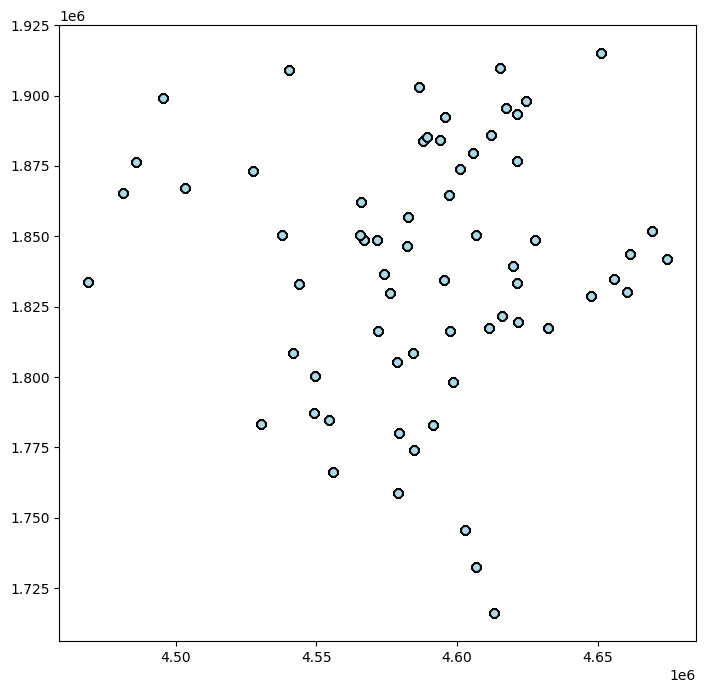

In [ ]:
gdf_est.plot(figsize=(10, 8), edgecolor="black", facecolor="lightblue")
plt.title("Visualización del Shapefile", fontsize=14)
plt.show()

In [ ]:
COLS_DERIVADAS = ['Fecha_t0_1d','Fecha_t0_3d','Fecha_t0_5d','Fecha_t0_7d','Fecha_t0_15d','Fecha_t0_30d','Fecha_t0_180d']


**Calendario de fechas a interpolar (t₀−ventanas, t₀ y t₀+1)**